# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# Quick clean: Ensure 'bpm' and other metrics are numeric
# Sometimes CSVs have stray characters; errors='coerce' turns them into NaN
cols_to_fix = ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=cols_to_fix, inplace=True)

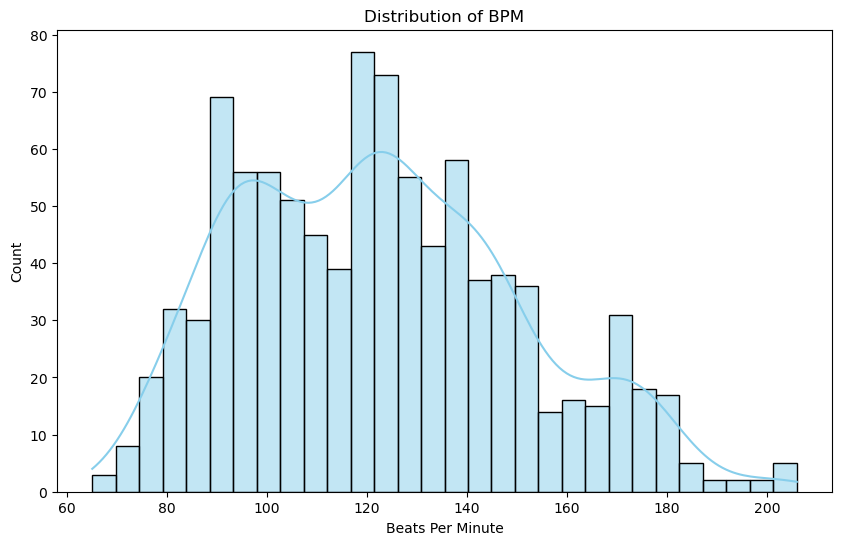

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['bpm'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of BPM')
plt.xlabel('Beats Per Minute')
plt.show()

C:\Users\Steve\AppData\Local\Temp\ipykernel_5008\3334705102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='key', data=df, order=df['key'].value_counts().index, palette='viridis')


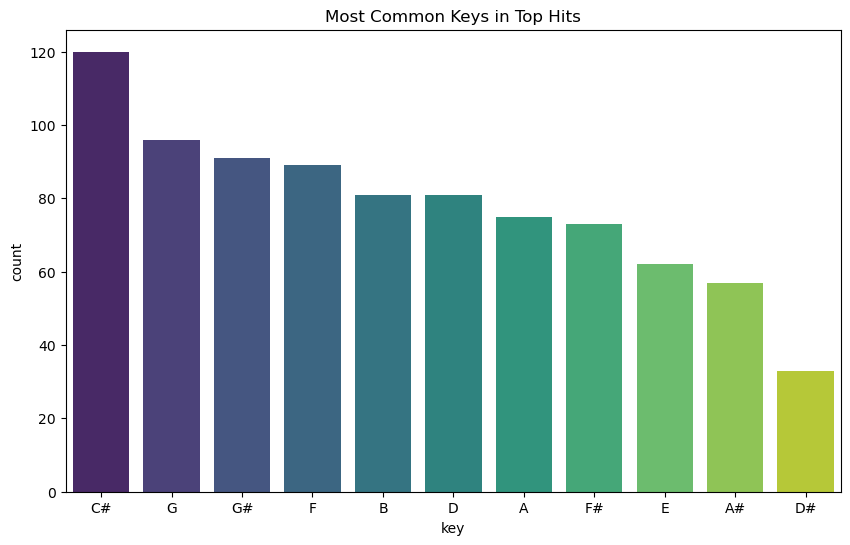

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(x='key', data=df, order=df['key'].value_counts().index, palette='viridis')
plt.title('Most Common Keys in Top Hits')
plt.show()

In [4]:
# This will give you the mean and quartiles for your ranges
print(df[['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']].describe())

# Find the most common Key and Mode
print(f"Top Key: {df['key'].mode()[0]}")
print(f"Top Mode: {df['mode'].mode()[0]}")

              bpm  danceability_%    energy_%  speechiness_%  acousticness_%
count  953.000000       953.00000  953.000000     953.000000      953.000000
mean   122.540399        66.96957   64.279119      10.131165       27.057712
std     28.057802        14.63061   16.550526       9.912888       25.996077
min     65.000000        23.00000    9.000000       2.000000        0.000000
25%    100.000000        57.00000   53.000000       4.000000        6.000000
50%    121.000000        69.00000   66.000000       6.000000       18.000000
75%    140.000000        78.00000   77.000000      11.000000       43.000000
max    206.000000        96.00000   97.000000      64.000000       97.000000
Top Key: C#
Top Mode: Major


In [5]:
# Replace these values with your actual findings from the visualizations
target_bpm_min, target_bpm_max = 110, 130
target_key = 'C#' 
target_mode = 'Major'

matches = df[
    (df['bpm'] >= target_bpm_min) & 
    (df['bpm'] <= target_bpm_max) &
    (df['key'] == target_key) &
    (df['mode'] == target_mode) &
    (df['danceability_%'] > 70) # Example threshold
]

print(f"Found {len(matches)} matches:")
print(matches[['track_name', 'artist(s)_name', 'streams']])

Found 11 matches:
                                       track_name  \
106                       Cold Heart - PNAU Remix   
166       Every Breath You Take - Remastered 2003   
168                                 We Found Love   
236  AMERICA HAS A PROBLEM (feat. Kendrick Lamar)   
271                                      PROVENZA   
589                                    Praise God   
692                          Gospel (with Eminem)   
778                                    Dos Mil 16   
787                                    ULTRA SOLO   
845                                  Belly Dancer   
864                              ULTRA SOLO REMIX   

                                        artist(s)_name     streams  
106                         Dua Lipa, Elton John, Pnau  1605224506  
166                                         The Police  1593270737  
168                             Rihanna, Calvin Harris  1235005533  
236                           Kendrick Lamar, Beyoncï¿    57089066  


Comparison Analysis: "Happy" by Pharrell Williams vs. My Engineered Hit

To test my data-driven model, I compared the global hit "Happy" to the criteria I established for a "guaranteed hit."

BPM: My engineered hit requires a range of 100–140 BPM. "Happy" (160 BPM) is a significant outlier here, being much faster than the statistical average.

Mode/Key: I determined that Major is the most successful mode. "Happy" actually uses F Minor, contradicting the typical hit profile.

Danceability & Energy: My model calls for high Danceability (>65%) and high Energy (>70%). "Happy" matches these perfectly, scoring roughly 70% for danceability and 80% for energy.

Conclusion: While "Happy" ignores the "ideal" tempo and key/mode of the Spotify 2023 dataset, it succeeds by doubling down on the Energy and Danceability metrics. This suggests that while a "data-perfect" song is a safe bet, extreme performance in specific categories can still create a smash hit.